In [1]:
import pandas as pd

In [2]:
import numpy as np

In [51]:
df1 = pd.read_excel("covid_19_dataset.xlsx" , sheet_name = "covid_19_deaths")

In [4]:
df2 = pd.read_excel("covid_19_dataset.xlsx" , sheet_name = "covid_19_confirmed")

In [5]:
df3 = pd.read_excel("covid_19_dataset.xlsx" , sheet_name = "covid_19_recovered")

In [52]:
df1.head(2)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,2772,2782,2792,2802,2812,2836,2855,2869,2881,2899
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,2440,2441,2442,2444,2445,2447,2447,2447,2448,2449


In [6]:
df2.head(2)

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,NaN,Afghanistan,33.93911,67.709953,0,0,0,0,0,0,...,64575,65080,65486,65728,66275,66903,67743,68366,69130,70111
1,NaN,Albania,41.15330,20.168300,0,0,0,0,0,0,...,132118,132153,132176,132209,132215,132229,132244,132264,132285,132297


In [53]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: float64(3), int64(493), object(2)
memory usage: 1.0+ MB


In [9]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 276 entries, 0 to 275
Columns: 498 entries, Province/State to 5/29/21
dtypes: float64(2), int64(494), object(2)
memory usage: 1.0+ MB


In [10]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 261 entries, 0 to 260
Columns: 498 entries, Province/State to 5/29/21
dtypes: float64(3), int64(493), object(2)
memory usage: 1015.6+ KB


In [9]:
import matplotlib.pyplot as plt

In [15]:
df2.columns

Index(['Province/State', 'Country/Region',            'Lat',           'Long',
              '1/22/20',        '1/23/20',        '1/24/20',        '1/25/20',
              '1/26/20',        '1/27/20',
       ...
              '5/20/21',        '5/21/21',        '5/22/21',        '5/23/21',
              '5/24/21',        '5/25/21',        '5/26/21',        '5/27/21',
              '5/28/21',        '5/29/21'],
      dtype='object', length=498)

In [10]:
country_data = df2.groupby('Country/Region').sum().drop(['Province/State','Lat', 'Long'], axis = 1)

In [26]:
country_data.index

Index(['Afghanistan', 'Albania', 'Algeria', 'Andorra', 'Angola',
       'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria',
       ...
       'United Kingdom', 'Uruguay', 'Uzbekistan', 'Vanuatu', 'Venezuela',
       'Vietnam', 'West Bank and Gaza', 'Yemen', 'Zambia', 'Zimbabwe'],
      dtype='object', name='Country/Region', length=193)

In [11]:
country_data.values

array([[     0,      0,      0, ...,  68366,  69130,  70111],
       [     0,      0,      0, ..., 132264, 132285, 132297],
       [     0,      0,      0, ..., 127926, 128198, 128456],
       ...,
       [     0,      0,      0, ...,   6696,   6723,   6731],
       [     0,      0,      0, ...,  93947,  94430,  94751],
       [     0,      0,      0, ...,  38854,  38918,  38933]],
      shape=(193, 494))

In [13]:
top_countries = country_data.iloc[:,1].sort_values(ascending=False).head(5).index

In [14]:
top_countries

Index(['China', 'Thailand', 'Vietnam', 'Japan', 'US'], dtype='object', name='Country/Region')

In [15]:
top_5 = country_data.loc[top_countries]

In [16]:
top_5 = top_5.T

In [17]:
top_5

Country/Region,China,Thailand,Vietnam,Japan,US
1/22/20,548,4,0,2,1
1/23/20,643,4,2,2,1
1/24/20,920,5,2,2,2
1/25/20,1406,6,2,2,2
1/26/20,2075,8,2,4,5
...,...,...,...,...,...
5/25/21,102905,135439,5931,726586,33166418
5/26/21,102925,137894,6086,731071,33190470
5/27/21,102932,143280,6356,735234,33217995
5/28/21,102948,147039,6396,738935,33239963


In [33]:
top_5.index = pd.to_datetime(top_5.index)

C:\Users\Mithun\AppData\Local\Temp\ipykernel_27588\2200696127.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  top_5.index = pd.to_datetime(top_5.index)


In [37]:
#sorting before plotting
top_5 = top_5.sort_index()

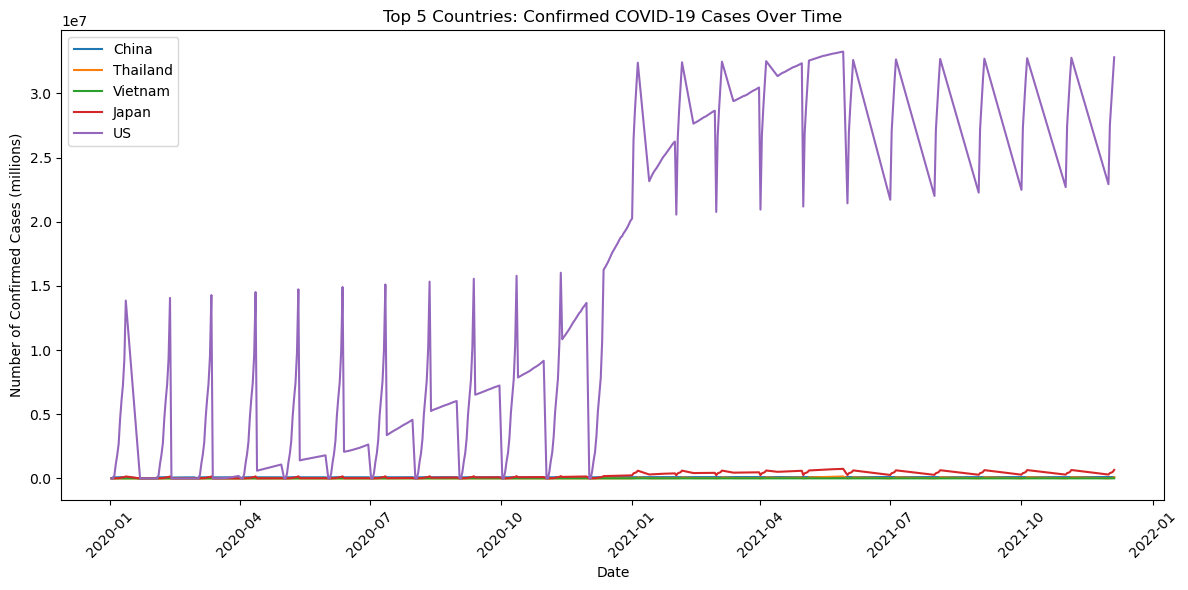

In [44]:
plt.figure(figsize =(12,6))
for country in top_5.columns:
    plt.plot(top_5.index, top_5[country], label=country)

# Add styling
plt.title('Top 5 Countries: Confirmed COVID-19 Cases Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Confirmed Cases (millions)')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [45]:
china_data = country_data.loc["China"]

In [48]:
#index to datetime
china_data.index = pd.to_datetime(china_data.index)

In [49]:
china_data = china_data.sort_index()

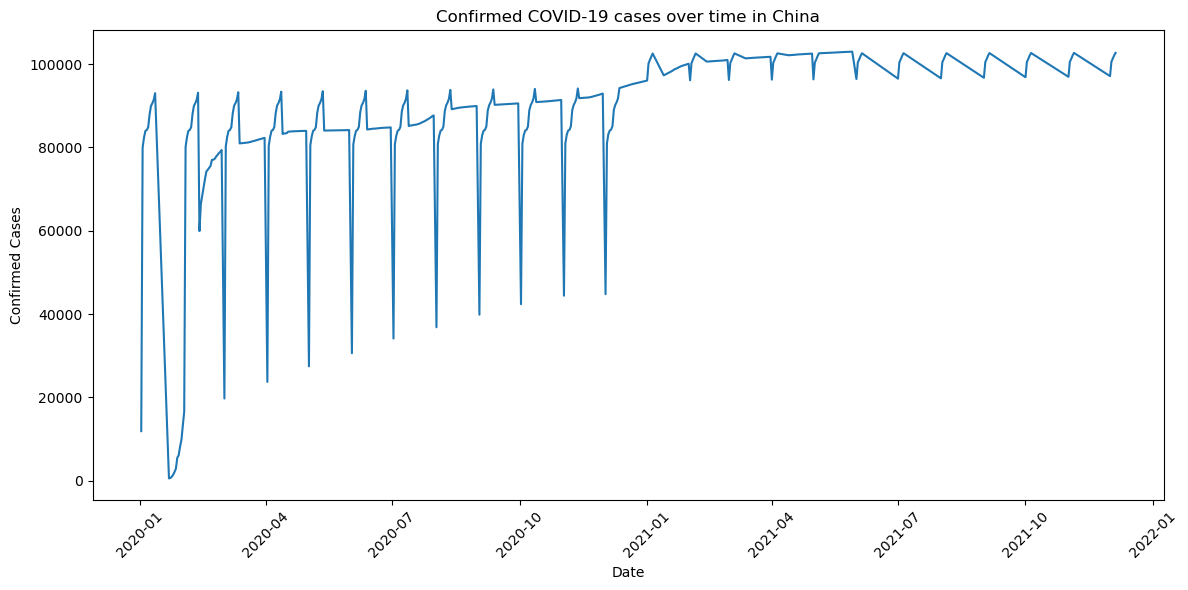

In [50]:
plt.figure(figsize=(12,6))
plt.plot(china_data.index, china_data.values)
plt.title("Confirmed COVID-19 cases over time in China")
plt.xlabel("Date")
plt.ylabel("Confirmed Cases")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [52]:
top_5.describe()

Country/Region,China,Thailand,Vietnam,Japan,US
count,494.000000,494.000000,494.000000,494.000000,4.940000e+02
mean,88056.334008,14451.983806,1246.931174,180954.421053,1.224238e+07
std,17205.298821,26012.110709,1171.917644,211372.761252,1.198808e+07
min,548.000000,4.000000,0.000000,2.000000,1.000000e+00
25%,84096.750000,3040.500000,325.250000,16456.250000,1.657099e+06
50%,90432.500000,3520.500000,1069.000000,80772.000000,7.013010e+06
75%,99506.250000,14646.000000,1550.500000,371579.750000,2.546674e+07
max,102960.000000,151842.000000,6908.000000,742539.000000,3.325194e+07


In [54]:
#checking for nulls
df1.isna().sum()

Province/State    190
Country/Region      0
Lat                 2
Long                2
1/22/20             0
                 ... 
5/25/21             0
5/26/21             0
5/27/21             0
5/28/21             0
5/29/21             0
Length: 498, dtype: int64

In [55]:
df1['Province/State'] = df1['Province/State'].fillna('All Provinces')

In [61]:
df2['Province/State'] = df2['Province/State'].fillna('All Provinces')
df3['Province/State'] = df3['Province/State'].fillna('All Provinces')

In [65]:
df3

,Province/State,Country/Region,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
0,All Provinces,Afghanistan,33.939110,67.709953,0,0,0,0,0,0,...,55687,55790,55889,56035,56295,56518,56711,56962,57119,57281
1,All Provinces,Albania,41.153300,20.168300,0,0,0,0,0,0,...,127869,128425,128601,128732,128826,128907,128978,129042,129097,129215
2,All Provinces,Algeria,28.033900,1.659600,0,0,0,0,0,0,...,87902,88066,88208,88346,88497,88672,88861,89040,89232,89419
3,All Provinces,Andorra,42.506300,1.521800,0,0,0,0,0,0,...,13234,13234,13234,13234,13234,13263,13381,13405,13416,13416
4,All Provinces,Angola,-11.202700,17.873900,0,0,0,0,0,0,...,26483,26513,26775,26778,27087,27204,27467,27529,27577,27646
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256,All Provinces,Vietnam,14.058324,108.277199,0,0,0,0,0,0,...,2687,2689,2721,2721,2794,2794,2853,2853,2896,2896
257,All Provinces,West Bank and Gaza,31.952200,35.233200,0,0,0,0,0,0,...,295643,296901,297201,297201,298502,299024,299559,299559,300125,300524
258,All Provinces,Yemen,15.552727,48.516388,0,0,0,0,0,0,...,3159,3179,3201,3245,3260,3273,3306,3339,3375,3399
259,All Provinces,Zambia,-13.133897,27.849332,0,0,0,0,0,0,...,90955,91019,91102,91156,91200,91221,91239,91321,91443,91594


In [71]:
# 5. which of these experianced the peak single day cases
countries = ['Germany','France', 'Italy']

In [72]:
df_filtererd = df2[df2['Country/Region'].isin(countries)]
df_grouped = df_filtererd.groupby('Country/Region').sum()

In [75]:
df_grouped

,Province/State,Lat,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
France,French GuianaFrench PolynesiaGuadeloupeMartini...,77.103595,-118.075614,0,0,2,3,3,3,4,...,5629983,5642786,5655397,5665101,5667331,5670486,5683143,5697076,5708350,5719877
Germany,All Provinces,51.165691,10.451526,0,0,0,0,0,1,4,...,3638504,3646600,3653019,3657662,3659990,3662568,3667041,3673990,3680159,3684672
Italy,All Provinces,41.871940,12.567380,0,0,0,0,0,0,0,...,4178261,4183476,4188190,4192183,4194672,4197892,4201827,4205970,4209707,4213055


In [77]:
daily_cases = df_grouped.iloc[:, 2:].diff(axis =1)

In [78]:
daily_cases

,Long,1/22/20,1/23/20,1/24/20,1/25/20,1/26/20,1/27/20,1/28/20,1/29/20,1/30/20,...,5/20/21,5/21/21,5/22/21,5/23/21,5/24/21,5/25/21,5/26/21,5/27/21,5/28/21,5/29/21
Country/Region,,,,,,,,,,,,,,,,,,,,,
France,NaN,118.075614,0,2,1,0,0,1,1,0,...,-348667,12803,12611,9704,2230,3155,12657,13933,11274,11527
Germany,NaN,-10.451526,0,0,0,0,1,3,0,0,...,10727,8096,6419,4643,2328,2578,4473,6949,6169,4513
Italy,NaN,-12.567380,0,0,0,0,0,0,0,0,...,5736,5215,4714,3993,2489,3220,3935,4143,3737,3348


In [79]:
for country in countries:
    max_val = daily_cases.loc[country].max()
    max_date = daily_cases.loc[country].idxmax()
    print(f"{country} peak: {int(max_val)} cases on {max_date}")

Germany peak: 49044 cases on 12/30/20
France peak: 117900 cases on 2021-11-04 00:00:00
Italy peak: 40902 cases on 11/13/20


In [81]:
# 5.2 which country showed better management of pandemic as of dec 31 2020
target_date = '12/31/20'
countries = ['Canada', 'Australia']

In [83]:
Total_confirm = df2.groupby('Country/Region')[target_date].sum()

In [84]:
Total_recover = df3.groupby('Country/Region')[target_date].sum()

In [85]:
for country in countries:
    confirmed = Total_confirm.loc[country]
    recovered = Total_recover.loc[country]
    
    # Calculate percentage
    rate = (recovered / confirmed) * 100
    print(f"{country} Recovery Rate on {target_date}: {rate:.2f}%")

Canada Recovery Rate on 12/31/20: 84.47%
Australia Recovery Rate on 12/31/20: 79.38%


In [90]:
# 5.3 Highest and lowest death rate among provinces in canada as of latest data point
latest_date = df2.columns[-1]

In [56]:
canada_confirmed = df2[df2['Country/Region'] == 'Canada']
canada_deaths = df1[df1['Country/Region'] == 'Canada']

In [97]:
# filter out rows where where cases are zeroes to avoid division by zero
canada_confirmed = canada_confirmed[canada_confirmed[latest_date] > 0]

In [98]:
conf_by_prov = canada_confirmed.set_index('Province/State')[latest_date]
deaths_by_prov = canada_deaths.set_index('Province/State')[latest_date]

In [99]:
death_rate = (deaths_by_prov/conf_by_prov)*100

In [100]:
death_rate = death_rate.dropna()

In [103]:
print("Death Rates by Province (%):")
print(death_rate)

print(f"\nHighest Death Rate: {death_rate.idxmax()} ({death_rate.max():.2f}%)")
print(f"Lowest Death Rate: {death_rate.idxmin()} ({death_rate.min():.2f}%)")

Death Rates by Province (%):
Province/State
Alberta                      0.975954
British Columbia             1.178429
Grand Princess               0.000000
Manitoba                     2.069348
New Brunswick                1.962574
Newfoundland and Labrador    0.460829
Northwest Territories        0.000000
Nova Scotia                  1.518987
Nunavut                      0.617284
Ontario                      1.619323
Prince Edward Island         0.000000
Quebec                       3.008969
Repatriated Travellers       0.000000
Saskatchewan                 1.155733
Yukon                        2.380952
Name: 5/29/21, dtype: float64

Highest Death Rate: Quebec (3.01%)
Lowest Death Rate: Grand Princess (0.00%)


In [57]:
# 6.1 Transforming deaths data from wide to long format
df_deaths_long = df1.melt(
    id_vars = ['Province/State', 'Country/Region', 'Lat', 'Long'],
    var_name = 'Date',
    value_name = 'Deaths'
)

In [29]:
df_deaths_long

,Province/State,Country/Region,Lat,Long,Date,Deaths
0,NaN,Afghanistan,33.939110,67.709953,1/22/20,0.0
1,NaN,Albania,41.153300,20.168300,1/22/20,0.0
2,NaN,Algeria,28.033900,1.659600,1/22/20,0.0
3,NaN,Andorra,42.506300,1.521800,1/22/20,0.0
4,NaN,Angola,-11.202700,17.873900,1/22/20,0.0
...,...,...,...,...,...,...
136339,NaN,Vietnam,14.058324,108.277199,5/29/21,47.0
136340,NaN,West Bank and Gaza,31.952200,35.233200,5/29/21,3492.0
136341,NaN,Yemen,15.552727,48.516388,5/29/21,1319.0
136342,NaN,Zambia,-13.133897,27.849332,5/29/21,1276.0


In [22]:
df_deaths_long['Date'] = pd.to_datetime(df_deaths_long['Date'])

C:\Users\Mithun\AppData\Local\Temp\ipykernel_3836\2315681109.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_deaths_long['Date'] = pd.to_datetime(df_deaths_long['Date'])


In [23]:
#
df_deaths_transformed = df_deaths_long.groupby(['Country/Region', 'Date'])['Deaths'].sum().reset_index()
print(df_deaths_transformed.head())

  Country/Region       Date  Deaths
0    Afghanistan 2020-01-22     0.0
1    Afghanistan 2020-01-23     0.0
2    Afghanistan 2020-01-24     0.0
3    Afghanistan 2020-01-25     0.0
4    Afghanistan 2020-01-26     0.0


In [26]:
filtered_df = df_deaths_transformed[df_deaths_transformed['Date'] == '2021-01-22']

In [27]:
filtered_df

,Country/Region,Date,Deaths
366,Afghanistan,2021-01-22,2370.0
860,Albania,2021-01-22,1303.0
1354,Algeria,2021-01-22,2856.0
1848,Andorra,2021-01-22,93.0
2342,Angola,2021-01-22,452.0
...,...,...,...
93238,Vietnam,2021-01-22,35.0
93732,West Bank and Gaza,2021-01-22,1769.0
94226,Yemen,2021-01-22,614.0
94720,Zambia,2021-01-22,610.0


In [32]:
# 6.2 Total number of deaths reported per country upto current date
latest_date = df_deaths_transformed['Date'].max()

In [33]:
total_deaths = df_deaths_transformed[df_deaths_transformed['Date'] == latest_date]

In [34]:
total_deaths[['Country/Region', 'Deaths']].sort_values(by='Deaths', ascending=False)

,Country/Region,Deaths
88919,US,594306.0
11855,Brazil,461057.0
39519,India,325972.0
57303,Mexico,223455.0
90895,United Kingdom,128037.0
...,...,...
25193,Dominica,0.0
57797,Micronesia,0.0
55821,Marshall Islands,0.0
37543,Holy See,0.0


In [35]:
# 6.3 Top 5 countries with highest average daily deaths
df_deaths_transformed['Daily_New_Deaths'] = df_deaths_transformed.groupby('Country/Region')['Deaths'].diff()

In [36]:
df_deaths_transformed['Daily_New_Deaths'] = df_deaths_transformed['Daily_New_Deaths'].fillna(0)

In [37]:
avg_daily_deaths = df_deaths_transformed.groupby('Country/Region')['Daily_New_Deaths'].mean().reset_index()

In [39]:
avg_daily_deaths.sort_values(by= 'Daily_New_Deaths', ascending=False).head(5)

,Country/Region,Daily_New_Deaths
179,US,1203.048583
23,Brazil,933.313765
79,India,659.862348
115,Mexico,452.338057
183,United Kingdom,259.184211


In [40]:
# 6.4 Cumulative total deaths Of USA
us_deaths = df_deaths_transformed[df_deaths_transformed['Country/Region'] == 'US']

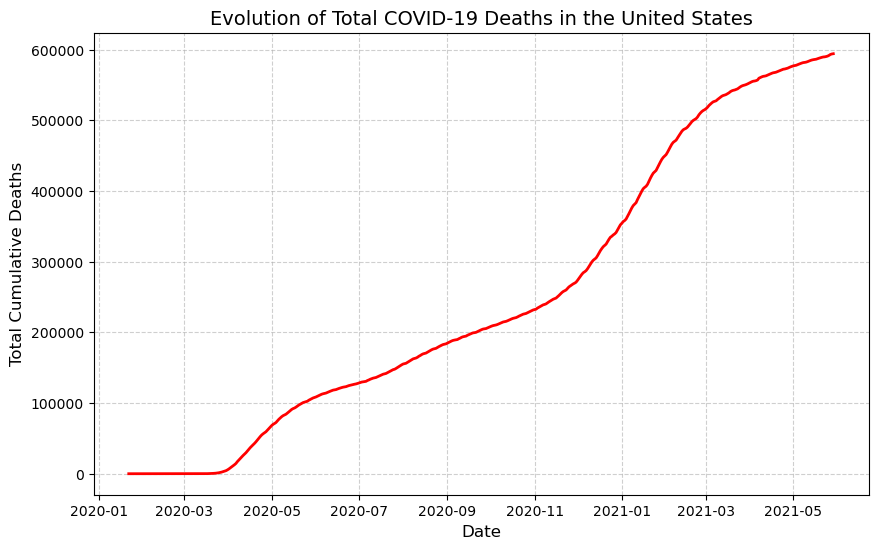

In [50]:
plt.figure(figsize =(10,6))
plt.plot(us_deaths['Date'], us_deaths['Deaths'], color= 'red',linewidth = 2)
plt.title('Evolution of Total COVID-19 Deaths in the United States', fontsize=14)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Cumulative Deaths', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [68]:
# 7.1 Transform all the datasets from wide to long for merging of Country and Date

def transform_to_long(df,value_name):
    df_long = df.melt(id_vars = ['Province/State', 'Country/Region', 'Lat', 'Long'],
                      var_name = 'Date',
                      value_name = value_name)
    
    df_long['Date'] = pd.to_datetime(df_long['Date'])
    df_long = df_long.groupby(['Country/Region', 'Date'])[value_name].sum().reset_index()
    
    return df_long
df_confirmed_long = transform_to_long(df2, 'Confirmed')
df_deaths_long = transform_to_long(df1, 'Deaths')
df_recovered_long = transform_to_long(df3, 'Recovered')


C:\Users\Mithun\AppData\Local\Temp\ipykernel_3836\51835071.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long['Date'] = pd.to_datetime(df_long['Date'])
C:\Users\Mithun\AppData\Local\Temp\ipykernel_3836\51835071.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long['Date'] = pd.to_datetime(df_long['Date'])
C:\Users\Mithun\AppData\Local\Temp\ipykernel_3836\51835071.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_long['Date'] = pd.to_datetime(df_long['Date'])


In [70]:
full_table = pd.merge(df_confirmed_long, df_deaths_long, on=['Country/Region', 'Date'], how ='left')

In [71]:
full_table = pd.merge(full_table, df_recovered_long, on=['Country/Region', 'Date'], how ='left')

In [72]:
full_table.head()

,Country/Region,Date,Confirmed,Deaths,Recovered
0,Afghanistan,2020-01-02,0,NaN,0.0
1,Afghanistan,2020-01-03,1,NaN,0.0
2,Afghanistan,2020-01-04,197,NaN,5.0
3,Afghanistan,2020-01-05,2291,NaN,310.0
4,Afghanistan,2020-01-06,15753,NaN,1428.0


In [73]:
# 7.2 Monthly sum of confirmed, death and recovery cases

full_table['Date']= pd.to_datetime(full_table['Date'])

In [75]:
full_table['Year']= full_table['Date'].dt.year
full_table['Month']= full_table['Date'].dt.month

In [76]:
monthly_summary = full_table.groupby(['Country/Region', 'Year', 'Month'])[['Confirmed', 'Deaths', 'Recovered']].sum().reset_index()

In [78]:
monthly_summary.head(5)

,Country/Region,Year,Month,Confirmed,Deaths,Recovered
0,Afghanistan,2020,1,252263,0.0,176248.0
1,Afghanistan,2020,2,253826,0.0,177059.0
2,Afghanistan,2020,3,256554,27.0,178750.0
3,Afghanistan,2020,4,279293,886.0,183696.0
4,Afghanistan,2020,5,442303,4939.0,200799.0


In [85]:
# 7.3 Monthly  sum of confirmed, death and recovery cases for USA , Italy, Brazil

target_countries = ['US', 'Italy', 'Brazil'] 

In [86]:
filtered_monthly = monthly_summary[monthly_summary['Country/Region'].isin(target_countries)]

In [87]:
filtered_monthly

,Country/Region,Year,Month,Confirmed,Deaths,Recovered
552,Brazil,2020,1,25512632,0.0,21484412.0
553,Brazil,2020,2,25726882,0.0,21770970.0
554,Brazil,2020,3,26022824,976.0,22009395.0
555,Brazil,2020,4,27123999,66331.0,22591844.0
556,Brazil,2020,5,32805161,502618.0,24932666.0
...,...,...,...,...,...,...
4315,US,2021,8,141971143,0.0,0.0
4316,US,2021,9,142489202,0.0,0.0
4317,US,2021,10,142958980,0.0,0.0
4318,US,2021,11,143422239,0.0,0.0


In [104]:
# 8.1 the three countries with the highest average death rates throughout the year 2020

data_2020 = full_table[full_table['Date'].dt.year == 2020].copy()

In [105]:
country_totals_2020 = data_2020.groupby('Country/Region')[['Confirmed', 'Deaths']].sum().reset_index()

In [106]:
country_totals_2020['Death Rate (%)'] = (country_totals_2020['Deaths'] / country_totals_2020['Confirmed']) * 100

In [115]:
country_totals_2020.sort_values(by='Death Rate (%)', ascending=False).head(3)

,Country/Region,Confirmed,Deaths,Death Rate (%)
190,Yemen,382306,105684.0,27.643825
105,MS Zaandam,2483,532.0,21.425695
115,Mexico,149022213,14587570.0,9.788856


In [117]:
country_totals_2020['Rank'] = country_totals_2020['Death Rate (%)'].rank(ascending=False)

# Look specifically for 'US'
print(country_totals_2020[country_totals_2020['Country/Region'] == 'US'])

    Country/Region   Confirmed      Deaths  Death Rate (%)  Rank
179             US  1727869552  45573135.0        2.637533  55.0


In [118]:
# 8.2 merged data for South Africa comparing the cumulative totals of recoveries versus deaths. 
sa_data = full_table[full_table['Country/Region'] == 'South Africa']

In [119]:
total_recoveries = sa_data['Recovered'].max()
total_deaths = sa_data['Deaths'].max()

In [120]:
print(f"South Africa - Total Recoveries: {total_recoveries}")
print(f"South Africa - Total Deaths: {total_deaths}")

South Africa - Total Recoveries: 1554184.0
South Africa - Total Deaths: 56363.0


In [121]:
recovery_to_death_ratio = total_recoveries / total_deaths
print(f"For every 1 death, there were approximately {round(recovery_to_death_ratio, 2)} recoveries.")

For every 1 death, there were approximately 27.57 recoveries.


In [123]:
# 8.3 monthly Recovery Ratio for the US from March 2020 to May 2021.

us_monthly = monthly_summary[
    (monthly_summary['Country/Region'] == 'US') & 
    ((monthly_summary['Year'] == 2020) & (monthly_summary['Month'] >= 3) | 
     (monthly_summary['Year'] == 2021) & (monthly_summary['Month'] <= 5))
    ]

In [124]:
us_monthly = us_monthly.copy()
us_monthly['Recovery Ratio'] = us_monthly['Recovered'] / us_monthly['Confirmed']

In [125]:
best_month = us_monthly.sort_values(by='Recovery Ratio', ascending=False).head(1)

print("Monthly Recovery Ratio for the US:")
print(us_monthly[['Year', 'Month', 'Recovery Ratio']])

Monthly Recovery Ratio for the US:
      Year  Month  Recovery Ratio
4298  2020      3        0.350569
4299  2020      4        0.297692
4300  2020      5        0.302140
4301  2020      6        0.319727
4302  2020      7        0.328080
4303  2020      8        0.353495
4304  2020      9        0.376939
4305  2020     10        0.387379
4306  2020     11        0.371003
4307  2020     12        0.064041
4308  2021      1        0.000000
4309  2021      2        0.000000
4310  2021      3        0.000000
4311  2021      4        0.000000
4312  2021      5        0.000000


In [126]:
print("\nMonth with the highest Recovery Ratio:")
print(best_month[['Year', 'Month', 'Recovery Ratio']])


Month with the highest Recovery Ratio:
      Year  Month  Recovery Ratio
4305  2020     10        0.387379
